# 04 — Feature Selection & Dimensionality Reduction

**Pipeline:** Mutual Information → **Top-20** features → **PCA → 10 latent dimensions** (optional Keras autoencoder alternative). Output → `data/latent_features.npy`, `data/mi_ranking.csv`, `artifacts/pca.pkl`.

In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd()
while not (REPO_ROOT / "src").exists() and REPO_ROOT.parent != REPO_ROOT:
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

print(REPO_ROOT)

D:\ChinarQAI\task6\v2\QWGAN_IDS


## 1. Mutual Information ranking

In [8]:
import pandas as pd
from src.feature_selection import compute_mutual_information

feature_matrix = pd.read_pickle(REPO_ROOT / "data" / "feature_matrix.pkl")
clean = pd.read_csv(REPO_ROOT / "data" / "kdd_clean.csv")

ranking = compute_mutual_information(feature_matrix, clean["label"])
ranking.head(20)

,feature,mutual_information,rank
0,src_bytes,1.024354,1
1,diff_srv_rate,0.663185,2
2,dst_host_diff_srv_rate,0.639798,3
3,dst_bytes,0.619820,4
4,same_srv_rate,0.616922,5
5,count,0.595377,6
6,dst_host_same_srv_rate,0.587964,7
7,dst_host_srv_count,0.573170,8
8,flag_SF,0.533417,9
9,dst_host_serror_rate,0.469914,10


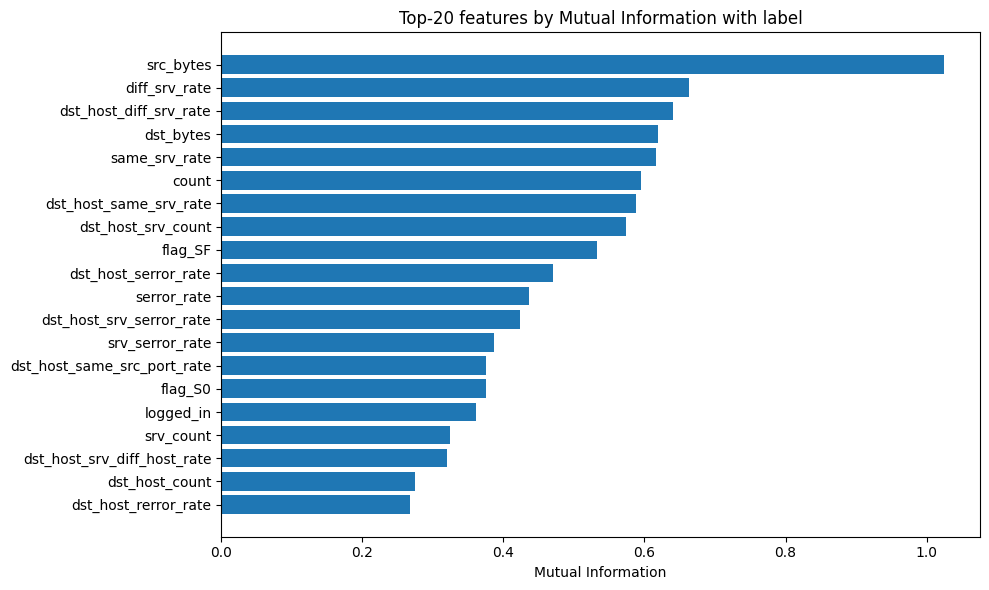

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.barh(ranking["feature"].head(20)[::-1],
         ranking["mutual_information"].head(20)[::-1])
plt.xlabel("Mutual Information")
plt.title("Top-20 features by Mutual Information with label")
plt.tight_layout()
plt.show()

## 2. Select top-20 → PCA → 10 latent dimensions

In [10]:
from src.feature_selection import select_top_k, apply_pca

top_feats = select_top_k(ranking, k=20)
X_top = feature_matrix[top_feats]

latent, pca, stats = apply_pca(
    X_top, n_components=10, random_state=42,
    artifact_dir=REPO_ROOT / "artifacts",
)
stats

[select] MI top-20 -> ['src_bytes', 'diff_srv_rate', 'dst_host_diff_srv_rate', 'dst_bytes', 'same_srv_rate', 'count', 'dst_host_same_srv_rate', 'dst_host_srv_count', 'flag_SF', 'dst_host_serror_rate', 'serror_rate', 'dst_host_srv_serror_rate', 'srv_serror_rate', 'dst_host_same_src_port_rate', 'flag_S0', 'logged_in', 'srv_count', 'dst_host_srv_diff_host_rate', 'dst_host_count', 'dst_host_rerror_rate']
[pca] latent: (147907, 10), cum. explained variance: 0.9981
[save] artifacts/pca.pkl


{'n_components': 10,
 'explained_variance_ratio': [0.7077938337759013,
  0.1555203355186445,
  0.07482618382787119,
  0.022717172446285364,
  0.019897636785426772,
  0.007992717110483993,
  0.004348100111205671,
  0.0031072616198044778,
  0.001114495445119083,
  0.0008081292416379405],
 'cumulative_explained_variance': 0.9981258658823804,
 'input_features': 20,
 'samples': 147907}

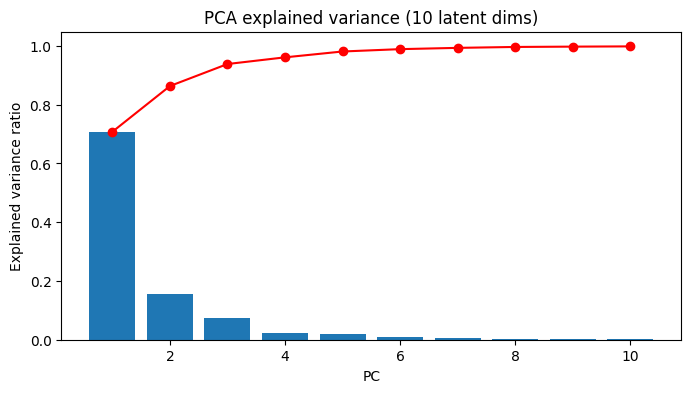

In [11]:
# Explained variance per principal component
import numpy as np

plt.figure(figsize=(8, 4))
plt.bar(range(1, 11), pca.explained_variance_ratio_)
plt.plot(range(1, 11), np.cumsum(pca.explained_variance_ratio_), "ro-")
plt.xlabel("PC"); plt.ylabel("Explained variance ratio")
plt.title("PCA explained variance (10 latent dims)")
plt.show()

In [12]:
# ============================================================
# 3. Persist outputs
# ============================================================
import joblib
import numpy as np

np.save(REPO_ROOT / "data" / "latent_features.npy", latent)
np.save(REPO_ROOT / "data" / "selected_feature_names.npy", np.array(top_feats))
ranking.to_csv(REPO_ROOT / "data" / "mi_ranking.csv", index=False)
joblib.dump(pca, REPO_ROOT / "artifacts" / "pca.pkl")
print("saved latent_features.npy, selected_feature_names.npy, mi_ranking.csv, pca.pkl")

saved latent_features.npy, selected_feature_names.npy, mi_ranking.csv, pca.pkl


## 4. (Optional) Autoencoder alternative — 10-dim latent vector

Requires TensorFlow. Uncomment and run to replace the PCA path.

In [13]:
# %%capture
# %pip install -q tensorflow

# from src.feature_selection import apply_autoencoder
# latent_ae, ae_model, history = apply_autoencoder(X_top, latent_dim=10, epochs=30)
# np.save(REPO_ROOT / "data" / "latent_features.npy", latent_ae)
# print("autoencoder latent saved:", latent_ae.shape)